# Exploration du dataset : Qui utilise mon appli ?

Notebook tiré du doc [Dataset : Qui utilise mon appli ?](https://claude.ai/code/artifact/914223c7-23d0-4c57-829a-92c595cff82a). Chaque section reprend le texte du doc,
suivi du code qui recalcule ses chiffres directement à partir des fichiers.

**Prérequis** : `pip install pandas matplotlib`, et les données dans `qui-utilise-mon-appli-v-2026-2027-groupe-2/`
à la racine du projet (fichiers `.GZ` laissés compressés).

In [1]:
import gzip
import re
from collections import Counter
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

DATA_DIR = Path("qui-utilise-mon-appli-v-2026-2027-groupe-2")

RE_TEMPS = re.compile(r"^t(\d+)$")              # marqueur de temps tXX
RE_TEMPS_COLLE = re.compile(r"^(.*\))(t\d+)$")  # marqueur collé à une action : "...Controller)t5"

## 1. Vue d'ensemble

On doit **prédire quel utilisateur (trigramme) a réalisé une session** sur le logiciel Copilote d'Infologic, à partir
de la seule trace de ses actions. C'est de la **classification multi-classe supervisée** : une ligne = une session,
une étiquette = un utilisateur.

La difficulté vient du format : chaque session est une **séquence de longueur variable** (actions + marqueurs de
temps), pas un tableau de colonnes fixes. Tout le travail de feature engineering consiste à transformer ces séquences
en vecteurs (comptages d'actions, écrans visités, rythme, navigateur, etc.).

## 2. Fichiers fournis

Trois fichiers suffisent : `train` pour apprendre, `test` pour prédire, `sample_submission` pour le format de rendu.

| Fichier | Contenu | Usage |
| --- | --- | --- |
| `train.csv.GZ` | Sessions **étiquetées** : `util, navigateur, actions...` | Entraînement + validation |
| `test.csv.GZ` | Sessions **sans étiquette** : `navigateur, actions...` | Prédiction finale |
| `sample_submission.csv` | `RowId,prediction` avec en-tête | Modèle du fichier à soumettre sur Kaggle |

Pièges de lecture :

- `train` et `test` sont **compressés en gzip** (extension `.GZ` en majuscules) et **sans ligne d'en-tête**.
- Dans `test`, la **première colonne est le navigateur** (pas de colonne `util`) : tout est décalé d'un cran.
- Les lignes n'ont pas le même nombre de champs. Un `pd.read_csv` naïf crée environ 14 470 colonnes remplies de NaN :
  on lit donc ligne par ligne avec `split(',')`, et on garde les actions dans une liste.
- Soumission : `RowId` = numéro de ligne du test **en partant de 1**, dans l'ordre du fichier ; `prediction` = le
  trigramme prédit.

In [2]:
def lire_lignes(nom_fichier: str) -> list[str]:
    """Lit un fichier gzip ligne par ligne (pas d'en-tête, nombre de champs variable)."""
    with gzip.open(DATA_DIR / nom_fichier, "rt", encoding="utf-8") as f:
        return [ligne.rstrip("\n") for ligne in f]


def nettoyer(tokens: list[str]) -> list[str]:
    """Normalise l'apostrophe typographique et sépare un marqueur tXX collé à une action."""
    propres = []
    for tok in tokens:
        tok = tok.replace("’", "'")
        colle = RE_TEMPS_COLLE.match(tok)
        propres.extend(colle.groups() if colle else [tok])
    return propres


def lire_sessions(nom_fichier: str, avec_util: bool) -> pd.DataFrame:
    """Une ligne = une session : [util,] navigateur, puis la liste des tokens (actions et marqueurs)."""
    sessions = []
    for ligne in lire_lignes(nom_fichier):
        champs = ligne.split(",")
        session = {"util": champs.pop(0)} if avec_util else {}
        session["navigateur"] = champs.pop(0)
        session["tokens"] = nettoyer(champs)
        sessions.append(session)
    return pd.DataFrame(sessions)


train = lire_sessions("train.csv.GZ", avec_util=True)
test = lire_sessions("test.csv.GZ", avec_util=False)
submission = pd.read_csv(DATA_DIR / "sample_submission.csv")

print(f"train : {len(train)} sessions | test : {len(test)} sessions | sample_submission : {len(submission)} lignes")
train.head()

train : 3279 sessions | test : 324 sessions | sample_submission : 324 lignes


,util,navigateur,tokens
0,nuh,Firefox,[Création d'un écran(infologic.core.accueil.Ac...
1,muz,Google Chrome,[Création d'un écran(infologic.core.gui.contro...
2,zrx,Microsoft Edge,[Affichage d'une dialogue(infologic.core.gui.c...
3,pou,Firefox,[Création d'un écran(infologic.core.gui.contro...
4,ald,Google Chrome,[Affichage d'une dialogue(infologic.acti.modul...


In [3]:
submission.head()

,RowId,prediction
0,1,abc
1,2,abc
2,3,abc
3,4,abc
4,5,abc


## 3. Format d'une ligne

Une ligne = une session. Les champs sont séparés par des virgules : `util, navigateur, action, action, t5, action, ..., tXX`.
Exemple de la consigne :

```
sph,Firefox,Exécution d'un bouton(fr.infologic.core.client.modules.web.CopiloteWebSharedController)<DEFAUT>$AC$,t5,Exécution d'un bouton,t10
```

| Position | Valeur | Signification |
| --- | --- | --- |
| 1 | `sph` | **util** : trigramme de l'utilisateur, la cible à prédire (absent du test) |
| 2 | `Firefox` | **navigateur** : Firefox, Google Chrome, Opera ou Microsoft Edge |
| 3 | `Exécution d'un bouton(...)<DEFAUT>$AC$` | Une action, enrichie d'un écran, d'une conf écran et d'une chaîne (section 4) |
| 4 | `t5` | Marqueur de temps : on a dépassé 5 s de session |
| 5 | `Exécution d'un bouton` | Action simple, sans contexte |
| 6 | `t10` | On a dépassé 10 s |

Les marqueurs `tXX` découpent la session en fenêtres de 5 s : les actions entre `t20` et `t25` ont eu lieu dans
l'intervalle [20 ; 25] s.

In [4]:
# Les 12 premiers tokens de la première session du train
exemple = train.loc[0, "tokens"][:12]
pd.DataFrame({
    "token": exemple,
    "nature": ["marqueur de temps" if RE_TEMPS.match(t) else "action" for t in exemple],
})

,token,nature
0,Création d'un écran(infologic.core.accueil.Acc...,action
1,Affichage d'une dialogue,action
2,Exécution d'un bouton,action
3,Fermeture d'une dialogue,action
4,Affichage d'une dialogue,action
5,Exécution d'un bouton,action
6,Fermeture d'une dialogue,action
7,Création d'un écran(infologic.core.gui.control...,action
8,t5,marqueur de temps
9,Exécution d'un bouton(MAINT),action


In [5]:
def marqueurs(tokens: list[str]) -> list[int]:
    """Valeurs (en secondes) des marqueurs tXX d'une session, dans l'ordre."""
    return [int(m.group(1)) for t in tokens if (m := RE_TEMPS.match(t))]


# Écart entre deux marqueurs consécutifs : 5 s attendu, 0 = même marqueur répété
pas = Counter()
for tokens in train["tokens"]:
    temps = marqueurs(tokens)
    pas.update(b - a for a, b in zip(temps, temps[1:]))

pas = pd.Series(pas).sort_index()
pd.DataFrame({"nb de pas": pas, "part": (pas / pas.sum()).map("{:.1%}".format)}).rename_axis("écart (s)")

,nb de pas,part
écart (s),,
0,24887,4.8%
5,489468,95.2%
10,52,0.0%
15,1,0.0%


Ce qu'on observe sur le train :

- 95,2 % des pas entre deux marqueurs valent 5 s ; 4,8 % sont un **même marqueur répété** (`t40,Double-clic,t40`) ;
  une cinquantaine de sauts de 10 s.
- Plusieurs marqueurs d'affilée sans action = **inactivité** (`t5,t10,t15`).
- Le dernier marqueur donne la **durée approximative** de la session.
- Le nombre d'actions par fenêtre donne la **vitesse** de l'utilisateur, une signature potentiellement très personnelle.

## 4. Anatomie d'une action

Chaque action suit le gabarit `Type(écran)<conf écran>$chaîne$1`. Seul le type est obligatoire ; les autres parties
sont optionnelles et apparaissent dans cet ordre.

| Partie | Délimiteur | Exemple |
| --- | --- | --- |
| Type d'action | aucun (début du champ) | `Saisie dans un champ` |
| Écran | `( )` | `(infologic.crm.modules.CRM_ANNUAIRE.AnnuaireController)` |
| Conf écran | `< >` | `<ACCUEIL_INST>` |
| Chaîne de la fiche | `$ $` | `$GP$` |
| Mode modification | `1` final | `Saisie dans un champ1` |

- **Écran** : indiqué quand l'utilisateur **navigue vers un autre écran**. Souvent une classe Java
  (`...PlanningController`), parfois un code court (`MAINT`, `DEV`). Pour connaître l'écran courant d'une action sans
  parenthèses, il faut propager le dernier écran vu.
- **Conf écran** : la configuration d'affichage choisie (`DEF_03/24`, `STD`, `INSTALLATEUR`...). Elle reflète souvent
  le **métier ou le profil** de l'utilisateur.
- **Chaîne** : le regroupement logique de la fiche travaillée (`VT`, `GP`, `EDI`...), répété sur chaque action tant
  qu'on reste sur la fiche.
- **`1` final** : l'utilisateur est en **modification** dans la fiche (et pas en simple consultation).

In [6]:
RE_ACTION = re.compile(
    r"^(?P<type>[^(<$]+?)"         # type d'action (obligatoire)
    r"(?:\((?P<ecran>.*)\))?"      # écran entre parenthèses (peut lui-même contenir des parenthèses)
    r"(?:<(?P<conf>[^>]*)>)?"      # conf écran entre balises
    r"(?:\$(?P<chaine>[^$]*)\$)?"  # chaîne de la fiche entre dollars
    r"(?P<modif>1)?$"              # 1 final = mode modification
)

# Une ligne par action, sans les marqueurs de temps (l'index garde le numéro de session)
tokens_train = train["tokens"].explode()
actions = tokens_train[~tokens_train.str.match(RE_TEMPS, na=True)].str.extract(RE_ACTION)
actions["util"] = train["util"].reindex(actions.index).to_numpy()

print(f"{len(actions):,} actions dans le train, dont {actions['type'].isna().sum()} non parsées")
actions.head()

2,270,247 actions dans le train, dont 0 non parsées


,type,ecran,conf,chaine,modif,util
0,Création d'un écran,infologic.core.accueil.AccueilController,NaN,NaN,NaN,nuh
0,Affichage d'une dialogue,NaN,NaN,NaN,NaN,nuh
0,Exécution d'un bouton,NaN,NaN,NaN,NaN,nuh
0,Fermeture d'une dialogue,NaN,NaN,NaN,NaN,nuh
0,Affichage d'une dialogue,NaN,NaN,NaN,NaN,nuh


In [7]:
parties = {"type": "Type d'action", "ecran": "Écran", "conf": "Conf écran",
           "chaine": "Chaîne de la fiche", "modif": "Mode modification"}
pd.DataFrame({
    "valeurs distinctes": [actions[p].nunique() for p in parties],
    "présence (% des actions)": [f"{actions[p].notna().mean():.1%}" for p in parties],
}, index=list(parties.values()))

,valeurs distinctes,présence (% des actions)
Type d'action,35,100.0%
Écran,415,12.7%
Conf écran,219,4.6%
Chaîne de la fiche,76,15.9%
Mode modification,1,15.6%


In [8]:
# Les 35 types d'actions, du plus au moins fréquent
actions["type"].value_counts().to_frame("nb d'actions")

,nb d'actions
type,
Exécution d'un bouton,510645
Saisie dans un champ,265633
Sélection d'un écran,206813
Fermeture d'une dialogue,171026
Affichage d'une dialogue,168928
Lancement d'une action générique,115283
Sélection d'un onglet,109209
Raccourci,82176
Création d'un écran,76930


Pièges de parsing repérés (déjà gérés par `nettoyer` et `RE_ACTION`) :

- `Sélection d’un onglet` utilise une **apostrophe typographique** (’) alors que les autres types utilisent `'`.
- Quelques écrans contiennent eux-mêmes des parenthèses (traces Java du type `...save (AbstractFBInputForm.java:195)`) :
  la regex non gourmande `\((.*?)\)` du notebook de consigne les coupe trop tôt.
- Le `1` de modification ne doit être retiré qu'en toute fin de champ : des confs comme `<001>` ou `<MT_AppelN1>`
  contiennent aussi des chiffres.
- Un marqueur peut être collé à une action (`...AccueilController)t5`).

In [9]:
brut = lire_lignes("train.csv.GZ")
print(f"Apostrophes typographiques dans le train brut : {sum(ligne.count('’') for ligne in brut):,}")
print(f"Marqueurs collés à une action : {[t for ligne in brut for t in ligne.split(',') if RE_TEMPS_COLLE.match(t)]}")
ecrans_imbriques = actions["ecran"].dropna().loc[lambda s: s.str.contains(r"\(")].unique()
print(f"Écrans contenant des parenthèses : {len(ecrans_imbriques)}")
del brut

Apostrophes typographiques dans le train brut : 109,209


Marqueurs collés à une action : ["Création d'un écran(infologic.core.accueil.AccueilController)t5"]
Écrans contenant des parenthèses : 2


## 5. Chiffres clés

Le train compte **3 279 sessions de 247 utilisateurs** ; le test, **324 sessions** à attribuer. Les deux jeux ont des
profils très proches (longueur, durée, navigateurs), ce qui suggère un découpage aléatoire.

In [10]:
for df in (train, test):
    df["nb_actions"] = df["tokens"].map(lambda ts: sum(not RE_TEMPS.match(t) for t in ts))
    df["duree"] = df["tokens"].map(lambda ts: max(marqueurs(ts), default=0))  # dernier tXX, en secondes


def tokens_distincts(df: pd.DataFrame) -> set[str]:
    return {t for ts in df["tokens"] for t in ts if not RE_TEMPS.match(t)}


voc_train, voc_test = tokens_distincts(train), tokens_distincts(test)
print(f"Tokens du test jamais vus dans le train : {len(voc_test - voc_train)} sur {len(voc_test)}")

pd.DataFrame({
    jeu: {
        "Sessions": len(df),
        "Utilisateurs distincts": df["util"].nunique() if "util" in df else "inconnu",
        "Actions par session, médiane": df["nb_actions"].median(),
        "Actions par session, min / max": f"{df['nb_actions'].min()} / {df['nb_actions'].max()}",
        "Durée médiane (s)": df["duree"].median(),
        "Durée max (s)": df["duree"].max(),
        "Tokens distincts (action + contexte)": len(voc),
    }
    for jeu, df, voc in [("train", train, voc_train), ("test", test, voc_test)]
})

Tokens du test jamais vus dans le train : 206 sur 2809


,train,test
Sessions,3279,324
Utilisateurs distincts,247,inconnu
"Actions par session, médiane",340.0,365.0
"Actions par session, min / max",0 / 11977,9 / 6203
Durée médiane (s),395.0,407.5
Durée max (s),11790,7110
Tokens distincts (action + contexte),7086,2809


In [11]:
navs_par_util = train.groupby("util")["navigateur"].nunique()
print(f"Utilisateurs avec un seul navigateur : {(navs_par_util == 1).sum()} / {len(navs_par_util)}")

pd.DataFrame({
    "utilisateurs": train.groupby("navigateur")["util"].nunique(),
    "sessions train": train["navigateur"].value_counts(),
    "sessions test": test["navigateur"].value_counts(),
}).sort_values("sessions train", ascending=False)

Utilisateurs avec un seul navigateur : 247 / 247


,utilisateurs,sessions train,sessions test
navigateur,,,
Firefox,114,1466,147
Google Chrome,93,1339,133
Microsoft Edge,39,451,42
Opera,1,23,2


**Le navigateur est constant par utilisateur** : chacun des 247 utilisateurs du train n'en utilise qu'un seul. Il
partitionne donc les candidats ; les 2 sessions Opera du test viennent très probablement de l'unique utilisateur Opera.

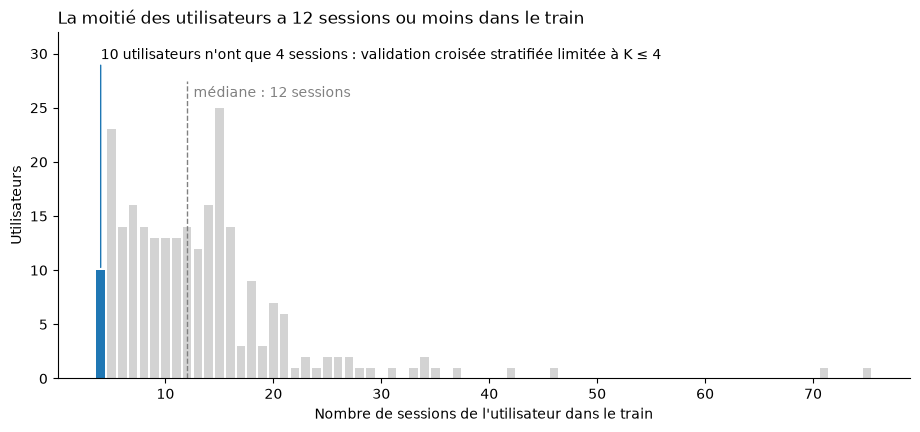

In [12]:
sessions_par_util = train["util"].value_counts()
mediane, mini = sessions_par_util.median(), sessions_par_util.min()
repartition = sessions_par_util.value_counts().sort_index()  # nb de sessions -> nb d'utilisateurs

fig, ax = plt.subplots(figsize=(11, 4.5))
ax.bar(repartition.index, repartition.values, width=0.8,
       color=["tab:blue" if n == mini else "lightgray" for n in repartition.index])
ax.vlines(mediane, 0, repartition.max() + 2.5, color="gray", linestyle="--", linewidth=1)
ax.text(mediane + 0.6, repartition.max() + 1, f"médiane : {mediane:.0f} sessions", color="gray")
ax.annotate(
    f"{repartition[mini]} utilisateurs n'ont que {mini} sessions : validation croisée stratifiée limitée à K ≤ {mini}",
    xy=(mini, repartition[mini]), xytext=(mini, repartition.max() + 4.5),
    arrowprops=dict(arrowstyle="-", color="tab:blue", relpos=(0, 0), shrinkA=0),
)
ax.set_ylim(0, repartition.max() + 7)
ax.set_xlabel("Nombre de sessions de l'utilisateur dans le train")
ax.set_ylabel("Utilisateurs")
ax.set_title(f"La moitié des utilisateurs a {mediane:.0f} sessions ou moins dans le train", loc="left")
ax.spines[["top", "right"]].set_visible(False)
plt.show()

Les classes sont déséquilibrées : suivre le **F1 macro** en plus de l'accuracy, et limiter la validation croisée
stratifiée à **K ≤ 4**, sinon scikit-learn signale des classes plus petites que le nombre de plis.

Valeurs aberrantes repérées :

- 3 sessions de moins de 5 actions, dont 1 sans aucune action (`fvc,Google Chrome,t5,t10,t15`) : candidates à la
  suppression dans le train.
- Des sessions très longues (jusqu'à 11 977 actions, plus de 3 h) : à garder, le test en contient aussi, mais il faut
  normaliser les comptages par la longueur de session.

In [13]:
colonnes = ["util", "navigateur", "nb_actions", "duree"]
display(train.loc[train["nb_actions"] < 5, colonnes])  # sessions quasi vides
train.nlargest(5, "nb_actions")[colonnes]              # sessions les plus longues

,util,navigateur,nb_actions,duree
1251,fvc,Google Chrome,0,15
2684,zus,Firefox,2,30
3141,fou,Google Chrome,1,5


,util,navigateur,nb_actions,duree
3082,wvy,Firefox,11977,11790
3234,fxg,Firefox,11505,9080
84,urs,Google Chrome,10625,8245
2812,wvy,Firefox,9707,10625
2520,fjb,Microsoft Edge,9430,8645


## 6. Glossaire et acronymes

Les termes du format sont définis par la consigne ; les codes de chaînes ne le sont pas, leur sens ci-dessous est
déduit des données et reste **à confirmer**.

| Terme | Sens |
| --- | --- |
| Copilote | Logiciel (ERP) édité par Infologic pour le secteur agroalimentaire, dont proviennent les traces |
| Trace | Journal des actions d'un utilisateur dans le logiciel |
| Session | Une utilisation continue du logiciel = une ligne du fichier |
| util / trigramme | Identifiant à 3 lettres de l'utilisateur (`nuh`, `skm`...) = la classe à prédire |
| Écran / Controller | Page du logiciel, souvent nommée par sa classe Java (`...AnnuaireController`) |
| Conf écran | Configuration d'affichage d'un écran (`STD`, `DEF_03/24`, `INSTALLATEUR`...) |
| Fiche | Un enregistrement métier ouvert dans un écran |
| Chaîne | Regroupement logique d'une fiche dans le logiciel (`$GP$`) |
| Mode modification | Fiche en édition, signalé par le `1` final |
| `tXX` | Marqueur de temps, par pas de 5 s |
| Toast | Notification éphémère affichée à l'écran |
| Infocentre | Module de reporting (package `infologic.infoc`, action « Lancement d'une action infocentre ») |
| Tomcat | Serveur d'applications Java ; son démarrage apparaît comme un événement de la trace |
| CRM | Gestion de la relation client (écrans `infologic.crm...`) |
| RowId | Numéro de ligne du test (à partir de 1) dans le fichier de soumission |

Les écrans `MAINT`, `DEV`, `BUG`, `PARAM` et `DOC` portent presque toutes les chaînes : ce sont vraisemblablement des
**types de fiches** (maintenance, développement, bug, paramétrage, documentation). Hypothèse : une partie des traces
vient d'équipes qui suivent des tickets par **module** du logiciel, ce qui rendrait la chaîne très révélatrice de
l'utilisateur. La cellule suivante le vérifie.

In [14]:
# Écran courant de chaque action : on propage le dernier écran vu dans la session
actions["ecran_courant"] = actions.groupby(level=0)["ecran"].ffill().to_numpy()

avec_chaine = actions[actions["chaine"].notna()]
types_fiches = ["MAINT", "DEV", "BUG", "PARAM", "DOC"]
print(f"Actions avec chaîne dont l'écran courant est {', '.join(types_fiches)} : "
      f"{avec_chaine['ecran_courant'].isin(types_fiches).mean():.1%}")

top_chaines = avec_chaine["chaine"].value_counts().head(14).index
(avec_chaine[avec_chaine["chaine"].isin(top_chaines)]
    .groupby("chaine")
    .agg(actions=("chaine", "size"),
         utilisateurs=("util", "nunique"),
         ecran_principal=("ecran_courant", lambda s: s.value_counts().index[0]))
    .sort_values("utilisateurs", ascending=False))

Actions avec chaîne dont l'écran courant est MAINT, DEV, BUG, PARAM, DOC : 99.7%


,actions,utilisateurs,ecran_principal
chaine,,,
OT,24509,162,MAINT
EDI,33359,124,MAINT
VT,53480,123,MAINT
ST,17160,115,MAINT
WEB,11410,113,BUG
TEC,26315,112,MAINT
GESCO,22173,111,DEV
SV,23681,111,MAINT
GP,39424,108,MAINT


| Code chaîne | Sens probable |
| --- | --- |
| `OT` | ? |
| `EDI` | Échange de données informatisé (standard) |
| `VT` | Ventes (package `infologic.ventes` présent) |
| `ST` | Stocks ? |
| `WEB` | Partie web du logiciel ? |
| `TEC` | Technique ? |
| `SV` | ? |
| `GESCO` | Gestion commerciale ? |
| `GP` | Gestion de production ? |
| `JCP` | ? |
| `DEVOPS` | DevOps ? |
| `ALCOOL` | Gestion des alcools (réglementation) ? |
| `MES` | Manufacturing Execution System (pilotage d'atelier) ? |
| `TRACE` | Traçabilité ? |

## 7. Réponses aux questions de la consigne

| Question | Réponse |
| --- | --- |
| De quels fichiers ai-je besoin ? | `train.csv.GZ` pour apprendre, `test.csv.GZ` pour prédire, `sample_submission.csv` pour le format de rendu |
| Quel format de données ? | CSV gzip sans en-tête, une session par ligne, nombre de champs variable : `[util,] navigateur, actions et marqueurs tXX` |
| Que dois-je prédire ? | Le trigramme de l'utilisateur pour chacune des 324 sessions du test, rendu en `RowId,prediction` |
| Quels acronymes ? | Voir le glossaire : termes du format, écrans courts (`MAINT`, `DEV`...) et codes de chaînes (`VT`, `GP`, `EDI`...) |
| Comment évaluer ? | Métrique officielle Kaggle : **score F1 moyen**. On suit le F1 macro et l'accuracy en validation croisée stratifiée (K = 4) |

Points à clarifier avec le prof :

- [x] Quelle est la **métrique officielle** du classement Kaggle ? → le **score F1 moyen** (page Kaggle). Reste à
  préciser : F1 macro (moyenne par utilisateur) ou « Mean F-Score » par ligne (équivalent à l'accuracy ici) ?
- [ ] Tous les utilisateurs du test sont-ils **présents dans le train** ?
- [ ] Le découpage train / test est-il **aléatoire ou temporel** ?
- [ ] Que signifient les codes de chaînes non identifiés (`OT`, `SV`, `JCP`...) ?
- [ ] Le navigateur est-il une feature légitime, sachant qu'il est **constant par utilisateur** dans le train ?

Contexte apporté par la page Kaggle : les utilisateurs sont des **testeurs internes** d'Infologic qui reportent les
problèmes rencontrés sous leur vrai profil (d'où les fiches `MAINT`, `DEV`, `BUG`...). Le but est de reconnaître un
utilisateur à sa façon d'utiliser le logiciel, avec une application possible en détection d'intrusion (quelqu'un
qui se connecte avec le compte d'un autre).